# K-Means Clustering Summary

## What is K-Means?
K-Means is an **unsupervised machine learning algorithm** used to group similar data points into **K clusters** based on feature similarity.

It tries to:
- Divide data into **K groups**
- Minimize the distance between data points and their cluster center (centroid)

---

## Type of Algorithm
- **Unsupervised Learning**
- **Clustering Algorithm**

---

## Main Goal
To partition the dataset into **K clusters** such that:

- Data points inside the same cluster are similar
- Data points in different clusters are dissimilar

---

## How K-Means Works (Steps)

1. Choose the number of clusters **K**
2. Randomly initialize **K centroids**
3. Assign each data point to the **nearest centroid**
4. Recalculate the centroid as the **mean of all points in that cluster**
5. Repeat steps 3 and 4 until:
   - Centroids stop changing, or
   - Cluster assignments no longer change

---

## Objective Function
K-Means minimizes the **Within-Cluster Sum of Squares (WCSS)**:

\[
J = \sum_{j=1}^{K} \sum_{x_i \in C_j} ||x_i - \mu_j||^2
\]

Where:
- \(K\) = number of clusters
- \(C_j\) = cluster \(j\)
- \(x_i\) = data point
- \(\mu_j\) = centroid of cluster \(j\)

---

## Distance Used
Most commonly uses:

- **Euclidean Distance**

\[
d(x, \mu) = \sqrt{(x_1 - \mu_1)^2 + (x_2 - \mu_2)^2 + \dots}
\]

---

## Output of K-Means
K-Means gives:

- **Cluster labels** for each data point
- **Centroids** of each cluster

---

## Example
Suppose customer ages and spending scores are given.

K-Means can group customers into clusters like:
- **Cluster 1:** Young high spenders
- **Cluster 2:** Middle-age moderate spenders
- **Cluster 3:** Older low spenders

This helps in:
- Customer segmentation
- Marketing strategies
- Personalized offers

---

## Advantages
- Simple and easy to understand
- Fast for large datasets
- Works well when clusters are clearly separated
- Easy to implement

---

## Disadvantages
- Need to choose **K** manually
- Sensitive to **initial centroid selection**
- Sensitive to **outliers**
- Works poorly with:
  - Non-spherical clusters
  - Different cluster sizes
  - Overlapping clusters

---

## How to Choose K
### Elbow Method
Plot:
- **K** vs **WCSS (inertia)**

Choose the point where the decrease in WCSS starts slowing down (the **elbow point**).

---

## Assumptions
K-Means works best when:
- Clusters are roughly **spherical**
- Clusters have similar sizes
- Features are scaled properly
- Data has low noise and fewer outliers

---

## Important Interview Points
- K-Means is **distance-based**
- It uses **centroids (mean points)**
- It minimizes **WCSS / inertia**
- It is sensitive to **feature scaling**
- Always consider **standardization/normalization** before applying
- Different initializations can give different results
- **K-Means++** is used to improve centroid initialization

---

## K-Means vs KNN
| Feature | K-Means | KNN |
|--------|--------|-----|
| Learning Type | Unsupervised | Supervised |
| Purpose | Clustering | Classification / Regression |
| Uses Labels? | No | Yes |
| Training Style | Finds clusters | Stores training data |
| Output | Cluster ID | Predicted class/value |

---

## Real-World Use Cases
- Customer segmentation
- Market basket analysis
- Image compression
- Document clustering
- Recommendation preprocessing
- Anomaly detection (basic grouping)
- Geo-clustering

---

## Common Limitations
- Choosing wrong **K** gives poor clusters
- Different runs may produce different results
- Outliers can pull centroids away
- Not suitable for categorical data directly

---

## Best Practices
- Scale features before applying K-Means
- Use **K-Means++**
- Try multiple values of **K**
- Use **Elbow Method** or **Silhouette Score**
- Remove extreme outliers if possible
- Run algorithm multiple times for stable results

---

## Short Interview Definition
**K-Means is an unsupervised clustering algorithm that divides data into K clusters by assigning each point to the nearest centroid and repeatedly updating centroids to minimize within-cluster variance (WCSS).**

---

## One-Line Summary
**K-Means groups similar data points into K clusters by minimizing the distance between points and their nearest cluster centroid.**

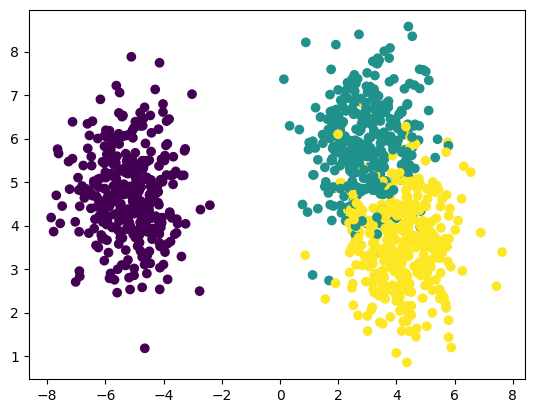

In [11]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

X,y=make_blobs(n_samples=1000,centers=3,n_features=2)

plt.scatter(X[:,0],X[:,1],c=y)

In [16]:
## standardization--feature scaling technique
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [19]:
# train split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X,y, test_size=0.33, random_state=42)


#  train data
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

from sklearn.cluster import KMeans

## Elbow method To select K Value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

wcss


[1339.9999999999998,
 715.5390673421783,
 330.5765898334415,
 258.0275230110088,
 174.32084344659592,
 151.72534062442585,
 115.86974569708421,
 96.77796279266248,
 90.47820522841116,
 81.74982500190177]

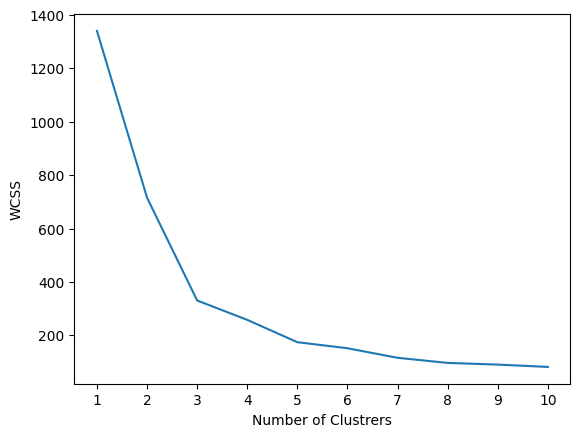

In [20]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clustrers")
plt.ylabel("WCSS")
plt.show()

#after k=3  , it is decreasing constant


In [21]:
# predict with K= 3
kmeans=KMeans(n_clusters=3,init="k-means++")
kmeans.fit_predict(X_train_scaled)

# predict
y_pred=kmeans.predict(X_test_scaled)

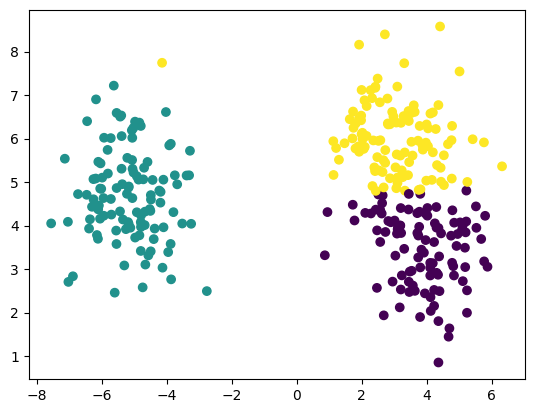

In [22]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

## Validating the k value
## kneelocator
## Silhoutee scoring

In [24]:
# we can also select k value using kneelocator, silhoutee scoring

## kneelocator
#%pip install kneed

from kneed import KneeLocator
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
kl.elbow

np.int64(3)

In [25]:
## silhoutte score
from sklearn.metrics import silhouette_score
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)
silhouette_coefficients

[0.5026028692247098,
 0.5500177041556562,
 0.49838510247726225,
 0.467419464277405,
 0.43451989495195115,
 0.42037598782561447,
 0.4088797178219607,
 0.39367141022382535,
 0.37036354203814664]

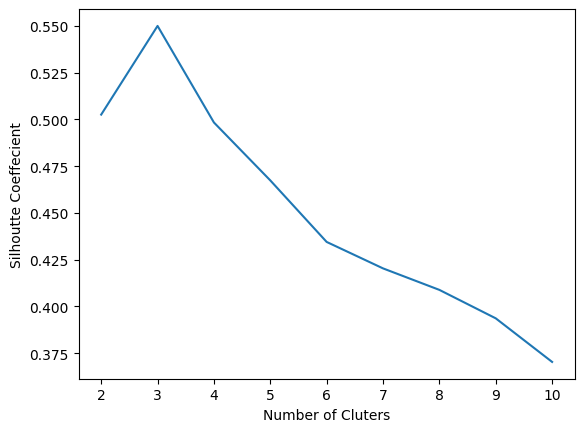

In [26]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()